In [2]:
# Bibliotheken importieren

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
import sqlalchemy
from dotenv import load_dotenv


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [1]:
# Datenbankverbindung prüfen

import os
from pathlib import Path
from dotenv import load_dotenv

env_path = Path(r"C:\Users\MamadouDianDiallo\Desktop\ASHRAE_Project\ASHRAE-Energy-Analysis\.env")

print(".env gefunden :", env_path.exists())

load_dotenv(env_path, override=True)

print("DB_HOST :", os.getenv("DB_HOST"))
print("DB_PORT :", os.getenv("DB_PORT"))
print("DB_USER :", os.getenv("DB_USER"))
print("DB_NAME :", os.getenv("DB_NAME"))
print("DB_PASSWORD geladen :", bool(os.getenv("DB_PASSWORD")))

.env gefunden : True
DB_HOST : 127.0.0.1
DB_PORT : 3306
DB_USER : Dian_Data
DB_NAME : ashrae_energy
DB_PASSWORD geladen : True


In [3]:
# Verbindung mit MySQL herstellen

import mysql.connector

connection = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME"),
    use_pure=True
)

print("Verbindung erfolgreich")

Verbindung erfolgreich


In [4]:
# SQLAlchemy-Verbindung

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT", "3306")
database = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+mysqlconnector://{user}:{quote_plus(password)}@{host}:{port}/{database}"
)

print("SQLAlchemy-Verbindung erfolgreich")

SQLAlchemy-Verbindung erfolgreich


In [20]:
### Étape 3 — Vérifier que pandas fonctionne
print("Pandas-Version:", pd.__version__)

Pandas-Version: 3.0.3


In [21]:
%pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
## Étape 6 — Lire les données avec Pandas

In [5]:
query = """
SELECT *
FROM ashrae_energy.train_full
LIMIT 10;
"""

df = pd.read_sql(query , engine)



df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008,None,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008,None,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008,None,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008,None,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008,None,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [31]:
## Étape 7 — Vérifier la structure des données

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   building_id         10 non-null     int64         
 1   meter               10 non-null     int64         
 2   timestamp           10 non-null     datetime64[us]
 3   meter_reading       10 non-null     float64       
 4   site_id             10 non-null     int64         
 5   primary_use         10 non-null     str           
 6   square_feet         10 non-null     int64         
 7   year_built          10 non-null     int64         
 8   floor_count         0 non-null      object        
 9   air_temperature     10 non-null     float64       
 10  cloud_coverage      5 non-null      float64       
 11  dew_temperature     10 non-null     float64       
 12  precip_depth_1_hr   9 non-null      float64       
 13  sea_level_pressure  9 non-null      float64       
 14  wind_dir

In [32]:
## Ensuite, vérifions les statistiques de base

df.describe()

,building_id,meter,timestamp,meter_reading,site_id,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,10.0,10.0,10,10.0,10.0,10.0,10.0,10.000000,5.00000,10.000000,9.000000,9.000000,10.000000,10.000000
mean,0.0,0.0,2016-01-01 04:30:00,0.0,0.0,7432.0,2008.0,21.660000,3.60000,20.500000,-0.333333,1019.500000,82.000000,0.710000
min,0.0,0.0,2016-01-01 00:00:00,0.0,0.0,7432.0,2008.0,19.400000,2.00000,19.400000,-1.000000,1018.100000,0.000000,0.000000
25%,0.0,0.0,2016-01-01 02:15:00,0.0,0.0,7432.0,2008.0,20.725000,2.00000,20.000000,-1.000000,1019.000000,0.000000,0.000000
50%,0.0,0.0,2016-01-01 04:30:00,0.0,0.0,7432.0,2008.0,21.100000,2.00000,20.600000,0.000000,1019.700000,0.000000,0.000000
75%,0.0,0.0,2016-01-01 06:45:00,0.0,0.0,7432.0,2008.0,22.375000,6.00000,21.100000,0.000000,1020.100000,175.000000,1.500000
max,0.0,0.0,2016-01-01 09:00:00,0.0,0.0,7432.0,2008.0,25.000000,6.00000,21.100000,0.000000,1020.200000,290.000000,2.600000
std,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1.831939,2.19089,0.616441,0.500000,0.736546,119.424546,0.970052


In [33]:
df.isnull().sum()

building_id            0
meter                  0
timestamp              0
meter_reading          0
site_id                0
primary_use            0
square_feet            0
year_built             0
floor_count           10
air_temperature        0
cloud_coverage         5
dew_temperature        0
precip_depth_1_hr      1
sea_level_pressure     1
wind_direction         0
wind_speed             0
dtype: int64

In [34]:
## Étape 8 — Vérifier les statistiques de base
df.describe()

,building_id,meter,timestamp,meter_reading,site_id,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,10.0,10.0,10,10.0,10.0,10.0,10.0,10.000000,5.00000,10.000000,9.000000,9.000000,10.000000,10.000000
mean,0.0,0.0,2016-01-01 04:30:00,0.0,0.0,7432.0,2008.0,21.660000,3.60000,20.500000,-0.333333,1019.500000,82.000000,0.710000
min,0.0,0.0,2016-01-01 00:00:00,0.0,0.0,7432.0,2008.0,19.400000,2.00000,19.400000,-1.000000,1018.100000,0.000000,0.000000
25%,0.0,0.0,2016-01-01 02:15:00,0.0,0.0,7432.0,2008.0,20.725000,2.00000,20.000000,-1.000000,1019.000000,0.000000,0.000000
50%,0.0,0.0,2016-01-01 04:30:00,0.0,0.0,7432.0,2008.0,21.100000,2.00000,20.600000,0.000000,1019.700000,0.000000,0.000000
75%,0.0,0.0,2016-01-01 06:45:00,0.0,0.0,7432.0,2008.0,22.375000,6.00000,21.100000,0.000000,1020.100000,175.000000,1.500000
max,0.0,0.0,2016-01-01 09:00:00,0.0,0.0,7432.0,2008.0,25.000000,6.00000,21.100000,0.000000,1020.200000,290.000000,2.600000
std,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1.831939,2.19089,0.616441,0.500000,0.736546,119.424546,0.970052


In [35]:
## Ensuite — Étape 9 : valeurs manquantes
df.isnull().sum()

building_id            0
meter                  0
timestamp              0
meter_reading          0
site_id                0
primary_use            0
square_feet            0
year_built             0
floor_count           10
air_temperature        0
cloud_coverage         5
dew_temperature        0
precip_depth_1_hr      1
sea_level_pressure     1
wind_direction         0
wind_speed             0
dtype: int64

In [36]:
df.describe()

,building_id,meter,timestamp,meter_reading,site_id,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,10.0,10.0,10,10.0,10.0,10.0,10.0,10.000000,5.00000,10.000000,9.000000,9.000000,10.000000,10.000000
mean,0.0,0.0,2016-01-01 04:30:00,0.0,0.0,7432.0,2008.0,21.660000,3.60000,20.500000,-0.333333,1019.500000,82.000000,0.710000
min,0.0,0.0,2016-01-01 00:00:00,0.0,0.0,7432.0,2008.0,19.400000,2.00000,19.400000,-1.000000,1018.100000,0.000000,0.000000
25%,0.0,0.0,2016-01-01 02:15:00,0.0,0.0,7432.0,2008.0,20.725000,2.00000,20.000000,-1.000000,1019.000000,0.000000,0.000000
50%,0.0,0.0,2016-01-01 04:30:00,0.0,0.0,7432.0,2008.0,21.100000,2.00000,20.600000,0.000000,1019.700000,0.000000,0.000000
75%,0.0,0.0,2016-01-01 06:45:00,0.0,0.0,7432.0,2008.0,22.375000,6.00000,21.100000,0.000000,1020.100000,175.000000,1.500000
max,0.0,0.0,2016-01-01 09:00:00,0.0,0.0,7432.0,2008.0,25.000000,6.00000,21.100000,0.000000,1020.200000,290.000000,2.600000
std,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1.831939,2.19089,0.616441,0.500000,0.736546,119.424546,0.970052


In [ ]:
df.isnull().sum()

In [39]:
query = """
SELECT *
FROM ashrae_energy.train_full
LIMIT 10000;
"""

df = pd.read_sql(query, connection)

print("Anzahl der Zeilen:", len(df))
print("Anzahl der Spalten:", len(df.columns))

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_27068\3290797944.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Anzahl der Zeilen: 10000
Anzahl der Spalten: 16


In [ ]:
df.isnull().sum()

In [ ]:
df.describe()

In [42]:
query = """
SELECT *
FROM ashrae_energy.train_full
ORDER BY RAND()
LIMIT 10000;
"""

df = pd.read_sql(query, connection)

print("Anzahl der Zeilen:", len(df))
print("Anzahl der Spalten:", len(df.columns))

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_27068\1034316164.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Anzahl der Zeilen: 10000
Anzahl der Spalten: 16


In [ ]:
## Étape suivante : vérifier les valeurs manquantes sur ce nouvel échantillon

df.isnull().sum()

In [ ]:
print("Meter:")
print(df["meter"].value_counts())

print("\nPrimary use:")
print(df["primary_use"].value_counts())

In [45]:
###vérifier les valeurs aberrantes

print("Valeurs négatives :", (df["meter_reading"] < 0).sum())
print("Valeurs nulles :", (df["meter_reading"] == 0).sum())
print("Valeur maximale :", df["meter_reading"].max())

Valeurs négatives : 0
Valeurs nulles : 970
Valeur maximale : 19463400.0


In [46]:
## Prochaine étape : identifier les valeurs extrêmes

df["meter_reading"].describe(percentiles=[0.90, 0.95, 0.99, 0.999])

count    1.000000e+04
mean     2.464154e+03
std      1.947501e+05
min      0.000000e+00
90%      8.327381e+02
95%      1.592541e+03
99%      5.808609e+03
99.9%    4.143863e+04
max      1.946340e+07
Name: meter_reading, dtype: float64

In [ ]:
## Étape suivante : identifier les 10 plus grandes consommations
df[["building_id", "meter", "primary_use", "square_feet", "meter_reading"]] \
    .sort_values("meter_reading", ascending=False) \
    .head(10)

In [ ]:
df["consumption_per_sqft"] = (
    df["meter_reading"] / df["square_feet"]
)

df[["meter_reading", "square_feet", "consumption_per_sqft"]].describe()

In [ ]:
# Verbrauch pro Quadratfuß berechnen
df["consumption_per_sqft"] = (
    df["meter_reading"] / df["square_feet"].replace(0, np.nan)
)

# Statistische Übersicht
df[["meter_reading", "square_feet", "consumption_per_sqft"]].describe()

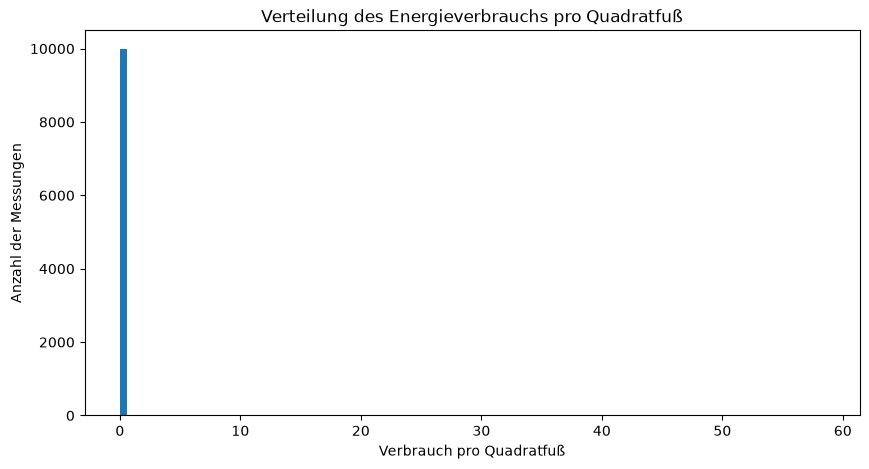

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(df["consumption_per_sqft"], bins=100)

plt.xlabel("Verbrauch pro Quadratfuß")
plt.ylabel("Anzahl der Messungen")
plt.title("Verteilung des Energieverbrauchs pro Quadratfuß")

plt.show()

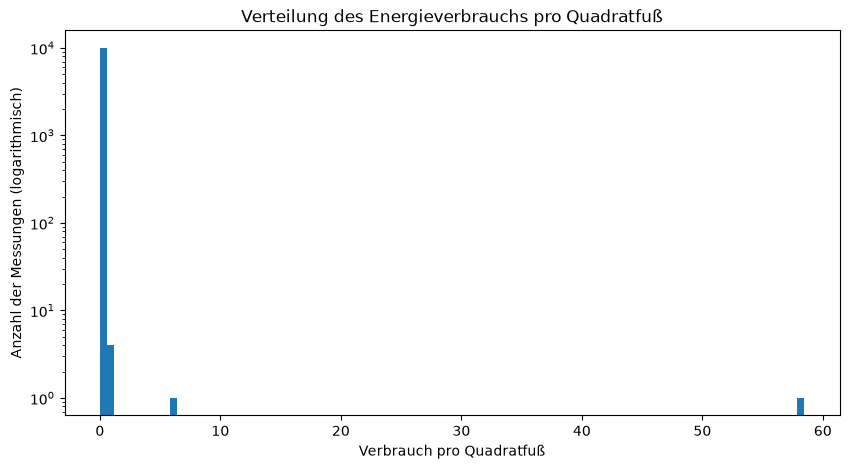

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["consumption_per_sqft"],
    bins=100,
    log=True
)

plt.xlabel("Verbrauch pro Quadratfuß")
plt.ylabel("Anzahl der Messungen (logarithmisch)")
plt.title("Verteilung des Energieverbrauchs pro Quadratfuß")

plt.show()

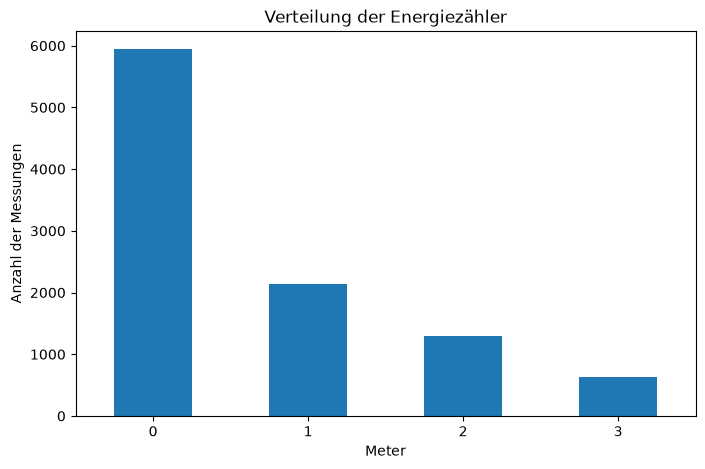

In [52]:
plt.figure(figsize=(8, 5))

df["meter"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Meter")
plt.ylabel("Anzahl der Messungen")
plt.title("Verteilung der Energiezähler")
plt.xticks(rotation=0)

plt.show()

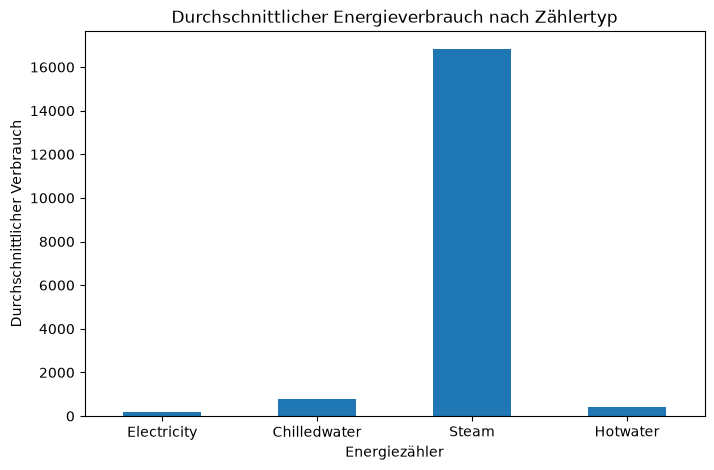

In [54]:
# Durchschnittlicher Verbrauch nach Energiezähler

meter_consumption = (
    df.groupby("meter")["meter_reading"]
    .mean()
)

meter_consumption.index = [
    "Electricity",
    "Chilledwater",
    "Steam",
    "Hotwater"
]

plt.figure(figsize=(8, 5))

meter_consumption.plot(kind="bar")

plt.xlabel("Energiezähler")
plt.ylabel("Durchschnittlicher Verbrauch")
plt.title("Durchschnittlicher Energieverbrauch nach Zählertyp")
plt.xticks(rotation=0)

plt.show()

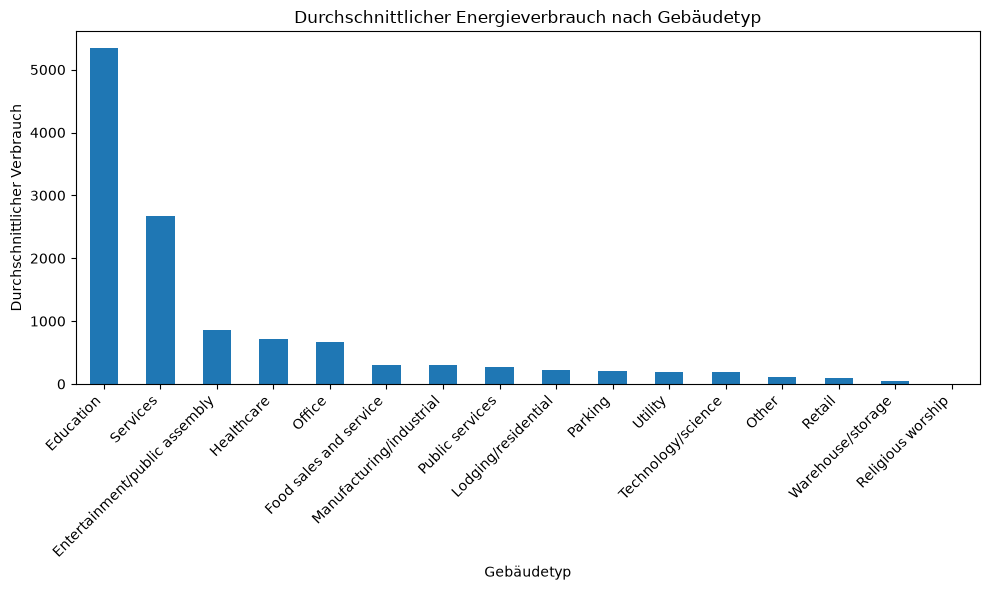

In [56]:
# Durchschnittlicher Verbrauch nach Gebäudetyp

building_consumption = (
    df.groupby("primary_use")["meter_reading"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

building_consumption.plot(kind="bar")

plt.xlabel("Gebäudetyp")
plt.ylabel("Durchschnittlicher Verbrauch")
plt.title("Durchschnittlicher Energieverbrauch nach Gebäudetyp")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

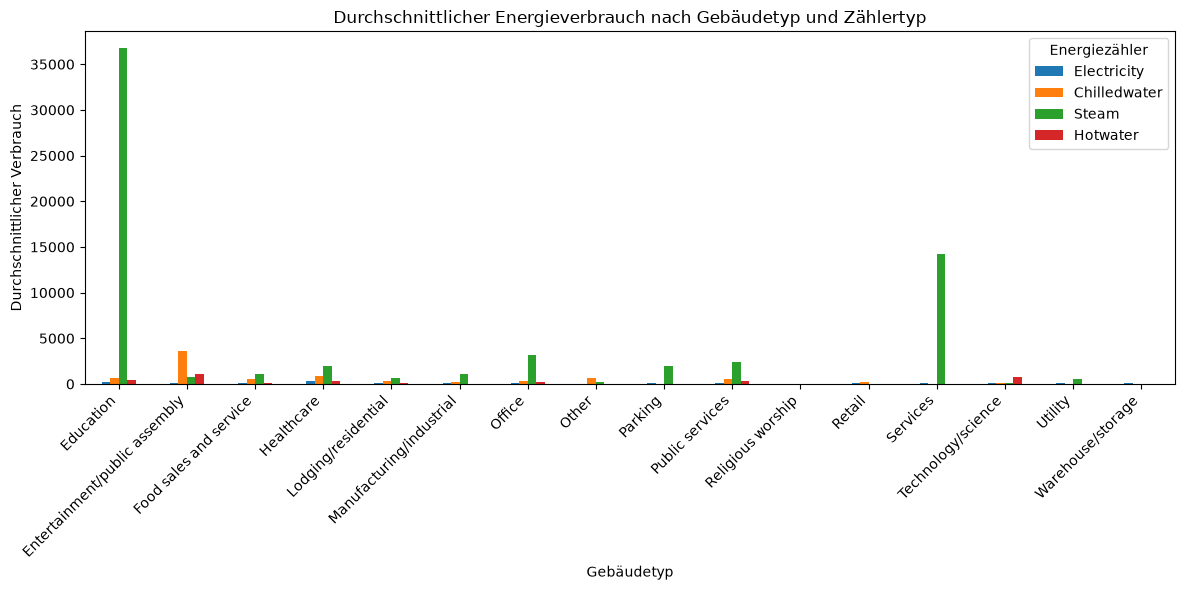

In [57]:
# Durchschnittlicher Verbrauch nach Gebäudetyp und Zählertyp

building_meter_consumption = (
    df.groupby(["primary_use", "meter"])["meter_reading"]
    .mean()
    .unstack()
)

building_meter_consumption.columns = [
    "Electricity",
    "Chilledwater",
    "Steam",
    "Hotwater"
]

building_meter_consumption.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Gebäudetyp")
plt.ylabel("Durchschnittlicher Verbrauch")
plt.title("Durchschnittlicher Energieverbrauch nach Gebäudetyp und Zählertyp")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Energiezähler")

plt.tight_layout()
plt.show()